## AVANCE 2 - DISEÑO DE LA SOLUCIÓN
presentación de los algoritmos seleccionados y demás especificaciones del modelo.

   1) Decision Tree Regressor
      - Justificación: Modelo base simple, permite análisis de complejidad
      - Parámetro clave: max_depth (analizamos convergencia)
   
   2) Random Forest Regressor  
      - Justificación: Múltiples árboles → mejor generalización
      - Paralela: Usa n_jobs=-1 (más rápido)



In [1]:
# Librerías necesarias
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
plt.style.use('ggplot')

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
# Definimos la ruta a los datos desde src hacia data
proyecto_root = Path.cwd().parent
ruta_X = proyecto_root / "data" / "X_modelo.csv"
ruta_y = proyecto_root / "data" / "y_modelo.csv"

# Cargar las bases de datos
X = pd.read_csv(ruta_X)
y = pd.read_csv(ruta_y)

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
X.head()

Dimensiones de X: (260853, 14)
Dimensiones de y: (260853, 1)


,edad,CANCER,DIABETES,ENF_CARDIACA,HIPERTENSION,ENF_PULMONAR,num_condiciones,meses_expuesto_total,Sexo_Cd_limpio_M,Sexo_Cd_limpio_NOBINARIO,CIUDAD_NORM_CALI,CIUDAD_NORM_CARTAGENA,CIUDAD_NORM_MEDELLIN,CIUDAD_NORM_SIN INFORMACION
0,57,0,0,0,0,0,0,11.991786,False,False,False,False,True,False
1,14,0,0,0,0,0,0,11.991786,True,False,False,False,True,False
2,11,0,0,0,0,0,0,11.991786,False,False,False,False,True,False
3,36,0,0,0,0,0,0,11.991786,False,False,False,True,False,False
4,16,0,0,0,0,0,0,11.991786,True,False,True,False,False,False


In [3]:
# Dividiendo los datos para entrenar Decission Tree Regresion - Random Forest

# Aseguramos  que 'y' sea un array 1D 
y_target = y['total_pagado'] if 'total_pagado' in y.columns else y.values.ravel()

#Dividimos los datos en 80% para entrenamiento y 20% para validación
X_train, X_val, y_train, y_val = train_test_split(X, y_target, test_size=0.2, random_state=42)

# Entrenamos el modelo Random Forest  SOLO con los datos de entrenamiento (X_train)
rf_inicial = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_inicial.fit(X_train, y_train)

# Entrenamos el modelo Decision Tree SOLO con los datos de entrenamiento (X_train)
dt_inicial = DecisionTreeRegressor(random_state=42)
dt_inicial.fit(X_train, y_train)   


DecisionTreeRegressor(random_state=42)

# Función para ejecutar algoritmo de Decision Tree Regressor

Analizando DecisionTree con profundidad entre 2 y 10

Depth 2: Train MSE = 25.7726, Val MSE = 26.2987, Diff = 0.5261
Depth 3: Train MSE = 25.0227, Val MSE = 25.5339, Diff = 0.5113
Depth 4: Train MSE = 24.5924, Val MSE = 25.1279, Diff = 0.5355
Depth 5: Train MSE = 24.3275, Val MSE = 24.8404, Diff = 0.5129
Depth 6: Train MSE = 24.1314, Val MSE = 24.6822, Diff = 0.5508
Depth 7: Train MSE = 23.9863, Val MSE = 24.6004, Diff = 0.6141
Depth 8: Train MSE = 23.8518, Val MSE = 24.5734, Diff = 0.7217
Depth 9: Train MSE = 23.7058, Val MSE = 24.6116, Diff = 0.9057
Depth 10: Train MSE = 23.5392, Val MSE = 24.6865, Diff = 1.1473


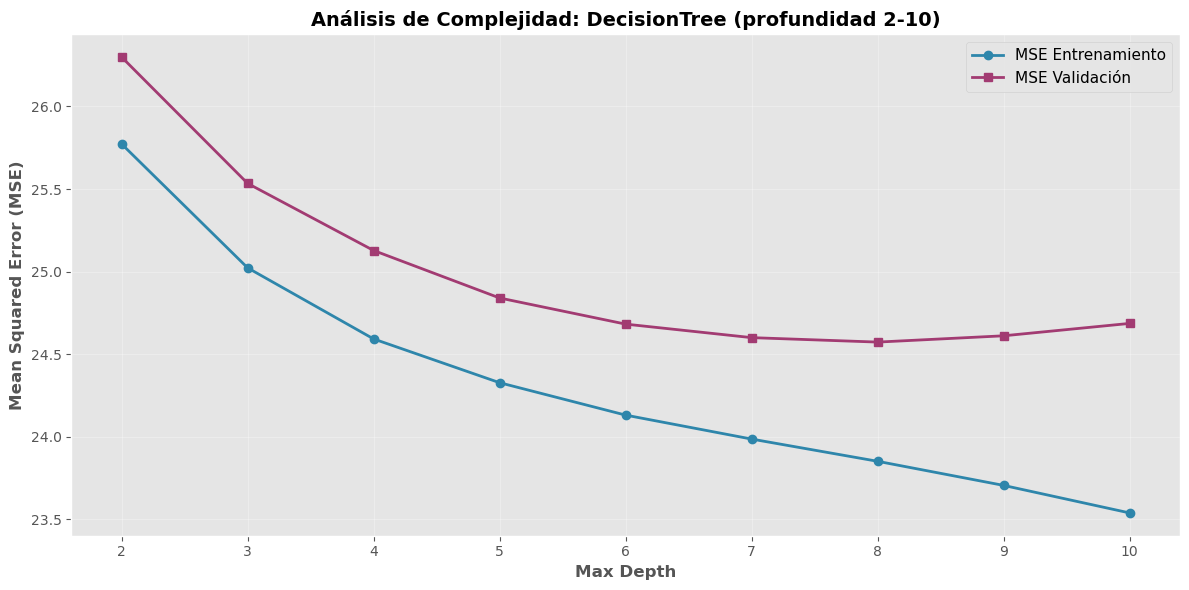

In [5]:
def analizar_decision_tree_complejidad(X_train, X_val, y_train, y_val, min_depth=2, max_depth=10):
    """
    Analiza la complejidad de DecisionTree variando max_depth
    y grafica la comparación MSE train vs validación
    
    Parámetros:
    - X_train, X_val: datos de entrenamiento y validación
    - y_train, y_val: targets de entrenamiento y validación
    - min_depth: profundidad mínima a probar (default=2)
    - max_depth: profundidad máxima a probar (default=10)
    """
    
    print(f"Analizando DecisionTree con profundidad entre {min_depth} y {max_depth}\n")
    
    train_errors = []
    val_errors = []
    depths = range(min_depth, max_depth + 1)
    
    # Entrenar árbol para cada profundidad
    for depth in depths:
        tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
        tree.fit(X_train, y_train)
        
        # Predicciones
        y_train_pred = tree.predict(X_train)
        y_val_pred = tree.predict(X_val)
        
        # Errores
        train_mse = mean_squared_error(y_train, y_train_pred)
        val_mse = mean_squared_error(y_val, y_val_pred)
        
        train_errors.append(train_mse)
        val_errors.append(val_mse)
        
        print(f"Depth {depth}: Train MSE = {train_mse:.4f}, Val MSE = {val_mse:.4f}, Diff = {val_mse - train_mse:.4f}")
    
    # Graficar resultados
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(depths, train_errors, marker='o', linewidth=2, label='MSE Entrenamiento', color='#2E86AB')
    ax.plot(depths, val_errors, marker='s', linewidth=2, label='MSE Validación', color='#A23B72')
    
    ax.set_xlabel('Max Depth', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
    ax.set_title('Análisis de Complejidad: DecisionTree (profundidad 2-10)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return train_errors, val_errors

# Ejecutar análisis
train_errors_dt, val_errors_dt = analizar_decision_tree_complejidad(X_train, X_val, y_train, y_val, min_depth=2, max_depth=10)



# COMPARACIÓN: CORRELACIÓN vs RELEVANCIA (Feature Importance) Para Algoritmo Decission Tree Regressor

Correlación mide relaciones LINEALES, pero Feature Importance mide relaciones de CUALQUIER tipo (lineal, no-lineal, complejas)

## Observación
Si una variable tiene ALTA Relevancia pero BAJA Correlación,
significa que tiene una relación NO-LINEAL con el objetivo

Calculando Correlación (Pearson) y Relevancia (Feature Importance)...

COMPARACIÓN: Correlación vs Relevancia (Decision Tree)


,Correlación (Abs),Relevancia (Árbol)
CANCER,0.062704,0.001835
CIUDAD_NORM_CALI,0.017937,0.020543
CIUDAD_NORM_CARTAGENA,0.027244,0.020338
CIUDAD_NORM_MEDELLIN,0.082145,0.019445
CIUDAD_NORM_SIN INFORMACION,0.010811,0.001072
DIABETES,0.047173,0.001225
ENF_CARDIACA,0.078185,0.001654
ENF_PULMONAR,0.056151,0.000970
HIPERTENSION,0.164493,0.002868
Sexo_Cd_limpio_M,0.140538,0.078540


/var/folders/wz/5knc4f1j3y1g1v82hm80x7g00000gn/T/ipykernel_47522/1208185411.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparativa['Correlación (Abs)'], y=comparativa.index, ax=ax[0], palette='Blues_r')
/var/folders/wz/5knc4f1j3y1g1v82hm80x7g00000gn/T/ipykernel_47522/1208185411.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparativa['Relevancia (Árbol)'], y=comparativa.index, ax=ax[1], palette='Greens_r')


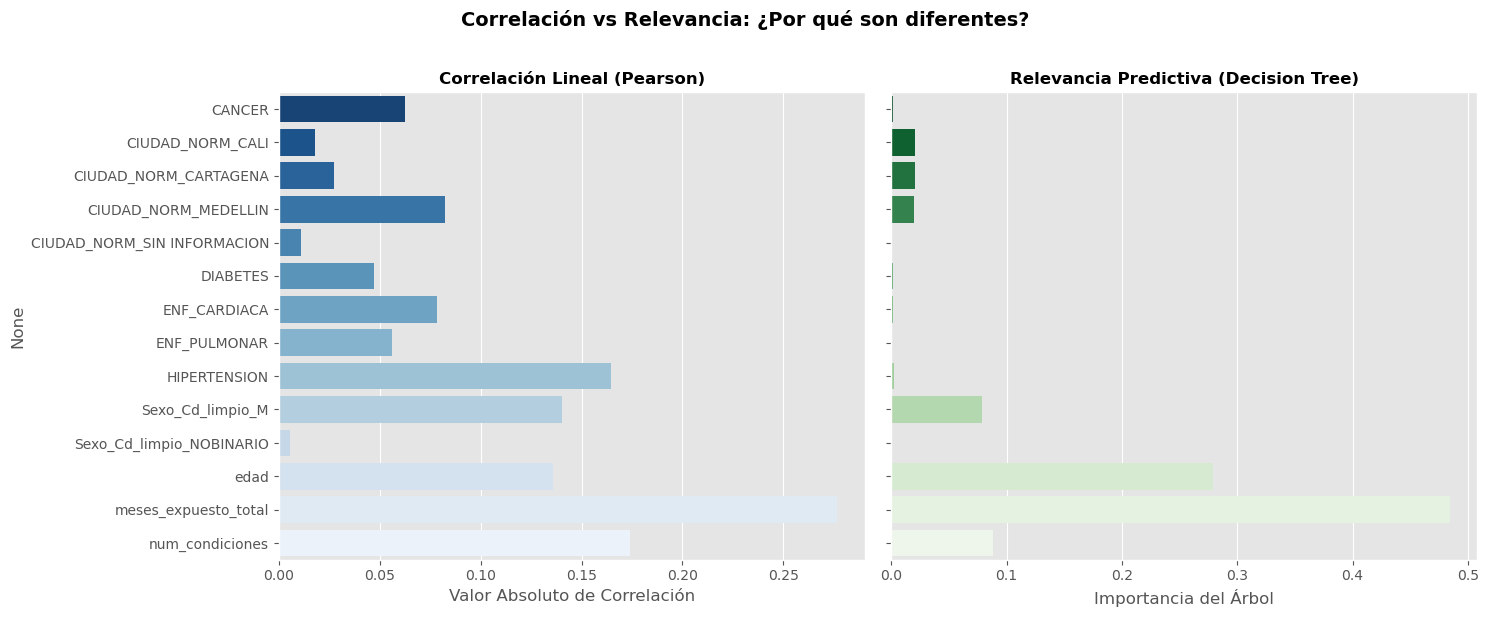

In [6]:
def comparar_correlacion_vs_importancia(X, y_target, modelo, nombre_modelo='Árbol'):
    """
    Compara Correlación de Pearson vs Feature Importance de un modelo
    
    Parámetros:
    - X: DataFrame con las features
    - y_target: Variable objetivo
    - modelo: Modelo entrenado (DecisionTree, RandomForest, etc.)
    - nombre_modelo: Nombre descriptivo del modelo para los títulos
    """
    
    print(f"Calculando Correlación (Pearson) y Relevancia (Feature Importance)...\n")
    
    # 1. Calcular Correlación de Pearson con el objetivo (valor absoluto)
    correlacion = X.corrwith(y_target).abs().sort_values(ascending=False)
    
    # 2. Extraer Feature Importance del modelo entrenado
    relevancia = pd.Series(
        modelo.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)
    
    # 3. Crear DataFrame comparativo
    comparativa = pd.DataFrame({
        'Correlación (Abs)': correlacion,
        'Relevancia (Árbol)': relevancia
    }).fillna(0)
    
    print("=" * 70)
    print(f"COMPARACIÓN: Correlación vs Relevancia ({nombre_modelo})")
    print("=" * 70)
    display(comparativa)
    
    # 4. Visualización comparativa
    fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    
    # Gráfico de Correlación
    sns.barplot(x=comparativa['Correlación (Abs)'], y=comparativa.index, ax=ax[0], palette='Blues_r')
    ax[0].set_title('Correlación Lineal (Pearson)', fontsize=12, fontweight='bold')
    ax[0].set_xlabel('Valor Absoluto de Correlación')
    
    # Gráfico de Relevancia
    sns.barplot(x=comparativa['Relevancia (Árbol)'], y=comparativa.index, ax=ax[1], palette='Greens_r')
    ax[1].set_title(f'Relevancia Predictiva ({nombre_modelo})', fontsize=12, fontweight='bold')
    ax[1].set_xlabel('Importancia del Árbol')
    
    plt.suptitle('Correlación vs Relevancia: ¿Por qué son diferentes?', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return comparativa

# Ejecutar análisis para Decision Tree
comparativa_dt = comparar_correlacion_vs_importancia(X, y_target, dt_inicial, nombre_modelo='Decision Tree')

# Función para ejecutar algoritmo de Random Forest Regressor

In [7]:

def analizar_random_forest_complejidad(X_train, X_val, y_train, y_val, 
                                       min_trees=10, max_trees=150, step=10):
    """
    Analiza cómo varía el MSE aumentando n_estimators en RandomForest
    """
    # Similar a DecisionTree, pero variando n_estimators en lugar de max_depth


# COMPARACIÓN: CORRELACIÓN vs RELEVANCIA (Feature Importance) Para Algoritmo Random Forest Regression

Calculando Correlación (Pearson) y Relevancia (Feature Importance)...

COMPARACIÓN: Correlación vs Relevancia (Random Forest)


,Correlación (Abs),Relevancia (Árbol)
CANCER,0.062704,0.002029
CIUDAD_NORM_CALI,0.017937,0.021533
CIUDAD_NORM_CARTAGENA,0.027244,0.019857
CIUDAD_NORM_MEDELLIN,0.082145,0.022967
CIUDAD_NORM_SIN INFORMACION,0.010811,0.001145
DIABETES,0.047173,0.001427
ENF_CARDIACA,0.078185,0.002161
ENF_PULMONAR,0.056151,0.001001
HIPERTENSION,0.164493,0.002679
Sexo_Cd_limpio_M,0.140538,0.073958


/var/folders/wz/5knc4f1j3y1g1v82hm80x7g00000gn/T/ipykernel_47522/1208185411.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparativa['Correlación (Abs)'], y=comparativa.index, ax=ax[0], palette='Blues_r')
/var/folders/wz/5knc4f1j3y1g1v82hm80x7g00000gn/T/ipykernel_47522/1208185411.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparativa['Relevancia (Árbol)'], y=comparativa.index, ax=ax[1], palette='Greens_r')


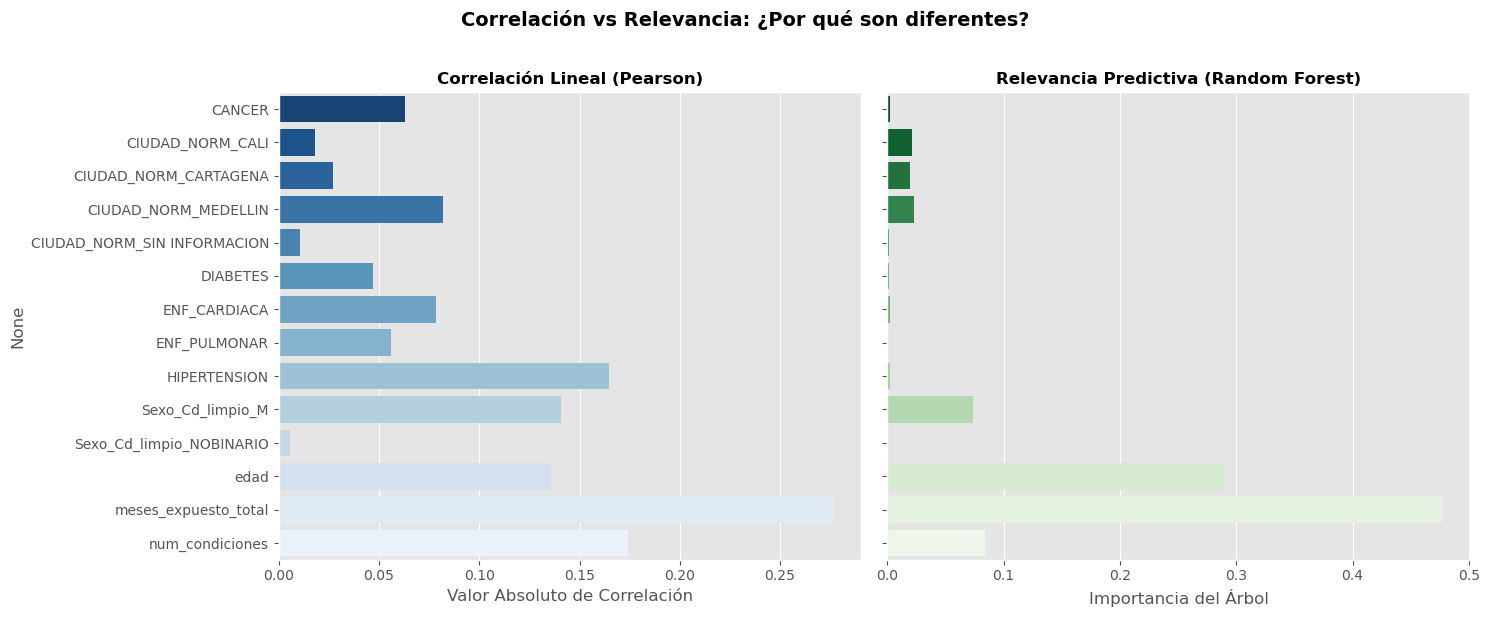

In [8]:
# Ejecutar análisis para Random Forest
comparativa_rf = comparar_correlacion_vs_importancia(X, y_target, rf_inicial, nombre_modelo='Random Forest')


# OPTIMIZACIÓN DE HIPERPARÁMETROS: GridSearchCV para RandomForest

GridSearchCV prueba TODAS las combinaciones de parámetros y encuentra la mejor usando Cross Validation.
Esto garantiza que los parámetros elegidos generalizan bien a datos nuevos.

In [ ]:
from sklearn.model_selection import GridSearchCV

print("=" * 80)
print("EJECUTANDO GridSearchCV para encontrar los MEJORES parámetros de RandomForest")
print("=" * 80)
print()

# Definir la grilla de parámetros a probar
param_grid_rf = {
    'n_estimators': [50, 100, 150],           # Cantidad de árboles
    'max_depth': [10, 20, 30, 50],            # Profundidad máxima
    'min_samples_split': [2, 5, 10],          # Muestras mínimas para dividir nodo
    'min_samples_leaf': [1, 2, 4],            # Muestras mínimas en hoja terminal
}

# Crear GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,  # 5-Fold Cross Validation
    scoring='neg_mean_squared_error',  # Optimiza por MSE
    n_jobs=-1,  # Paralela todos los núcleos
    verbose=1
)

# Ejecutar búsqueda
print("Buscando la mejor combinación de parámetros")
grid_search.fit(X_train, y_train)

print("\n" + "=" * 80)
print("RESULTADOS DE LA BÚSQUEDA")
print("=" * 80)
print(f"\n✓ Mejores parámetros encontrados:")
for param, valor in grid_search.best_params_.items():
    print(f"  • {param}: {valor}")

print(f"\n✓ Mejor score (R² negativo en CV): {grid_search.best_score_:.6f}")
print(f"✓ Score en validación (R²): {grid_search.best_estimator_.score(X_val, y_val):.6f}")

# Comparar con el modelo inicial
print(f"\n✓ Score del Random Forest INICIAL (sin optimizar): {rf_inicial.score(X_val, y_val):.6f}")

# Guardar el mejor modelo
rf_optimizado = grid_search.best_estimator_
print(f"\n✓ Modelo optimizado guardado en: rf_optimizado")

# Mostrar tabla de todos los resultados
print("\n" + "=" * 80)
print("TOP 10 MEJORES COMBINACIONES DE PARÁMETROS")
print("=" * 80)
resultados_df = pd.DataFrame(grid_search.cv_results_)
top_10 = resultados_df[['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 
                          'param_min_samples_leaf', 'mean_test_score', 'std_test_score']].head(10)
print(top_10.to_string())

EJECUTANDO GridSearchCV para encontrar los MEJORES parámetros de RandomForest

Buscando la mejor combinación de parámetros...
(Esto puede tomar 1-2 minutos dependiendo de tu CPU)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
